# Predicción de precios de vivienda (House Prices, Kaggle)

## Contexto y objetivo técnico del notebook
Este proyecto se enmarca en un problema real del ámbito financiero-inmobiliario: estimar el valor de mercado de una vivienda a partir de sus características (superficie, calidad de construcción, barrio, año, garaje, etc.). Este tipo de modelos se utiliza en tasación automática, análisis de inversión inmobiliaria y estimación de riesgos (por ejemplo, en hipotecas).

Desde el punto de vista de Machine Learning, este es un problema de **regresión supervisada**:
- Tenemos un conjunto de ejemplos (viviendas) con variables explicativas (**features**) y una variable objetivo (**target**).
- El objetivo es aproximar una función \( f(\mathbf{x}) \approx y \), donde \( y \) es el precio de venta.



En las siguientes celdas:
1) configuramos el entorno (reproducibilidad),
2) cargamos los datos,
3) hacemos una inspección inicial para detectar problemas típicos (valores faltantes, variables categóricas, escalas),
4) definimos la métrica y estrategia de validación.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


## Carga de datos desde archivos locales

En lugar de descargar mediante Kaggle API, cargamos `train.csv` y `test.csv` desde la carpeta local del proyecto (la misma donde está el notebook). 



En esta celda:
- Leemos ambos CSV con pandas.
- Verificamos dimensiones (número de filas/columnas).
- Hacemos una primera inspección (`head`) para entender el esquema del dataset.


In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.head()


Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Definición formal del problema: X (features) e y (target)

En un proyecto de aprendizaje supervisado es crucial separar explícitamente:
- **y**: variable objetivo (lo que queremos predecir).
- **X**: variables predictoras (lo que el modelo usa como entrada).

En este dataset:
- La variable objetivo es `SalePrice` (precio de venta).
- Además, existe un identificador `Id` que NO es una característica real del inmueble, sino una clave administrativa. 
  - Por ello, normalmente se excluye del entrenamiento como feature (evitamos que el modelo “memorice” IDs).
  - Pero lo guardamos porque Kaggle exige incluirlo al crear la submission.

En esta celda:
- Extraemos `y = SalePrice`.
- Creamos `X` eliminando `SalePrice`.
- Guardamos los IDs del test para el archivo final de predicción.


In [3]:
TARGET = "SalePrice"

y = train_df[TARGET].copy()
X = train_df.drop(columns=[TARGET])

test_ids = test_df["Id"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1460, 80)
y shape: (1460,)


## Diagnóstico inicial de calidad del dato: tipos y valores faltantes

Antes de modelar, necesitamos entender dos cosas fundamentales:

### 1) Tipos de variables
En datasets tabulares suelen coexistir:
- **Numéricas** (int, float): superficies, años, conteos...
- **Categóricas** (object): barrio, tipo de casa, calidad, etc.

Esto es importante porque:
- Los modelos necesitan entrada numérica.
- Las variables categóricas deben codificarse (por ejemplo, One-Hot).
- Muchas variables requieren tratamiento especial si son ordinales (calidades, estados), algo que trataremos más adelante.

### 2) Missing values (valores faltantes)
Este dataset es conocido por tener MUCHOS missing values en varias columnas.
Los faltantes pueden representar:
- información desconocida,
- ausencia real de una característica (p.ej., no hay piscina),
- datos no recogidos.



En esta celda:
- Revisamos `dtypes`.
- Calculamos el porcentaje de NA por columna y mostramos las más problemáticas.


In [4]:
dtypes = X.dtypes.value_counts()
print("Distribución de tipos:\n", dtypes, "\n")

missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(20)


Distribución de tipos:
 object     43
int64      34
float64     3
Name: count, dtype: int64 



PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageQual       5.547945
GarageFinish     5.547945
GarageCond       5.547945
GarageYrBlt      5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtFinType1     2.534247
BsmtQual         2.534247
BsmtCond         2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

## EDA del target: distribución de precios y motivación de la transformación log

En regresión, la distribución del target es crítica. En precios de vivienda es común ver:
- una distribución asimétrica (cola larga a la derecha),
- varianza creciente con el nivel del precio (heteroscedasticidad),
- outliers de viviendas muy caras.

Muchos modelos funcionan mejor cuando:
- los errores se penalizan en escala relativa,
- se estabiliza la varianza,
- y la distribución se aproxima a algo más “gaussiano”.

Por eso, en esta competición de Kaggle, es habitual aplicar:
\[
y' = \log(1 + y)
\]
donde usamos `log1p` para manejar correctamente valores y evitar problemas numéricos.

En esta celda:
- Graficamos el histograma de `SalePrice`.
- Graficamos el histograma de `log1p(SalePrice)`.
Esto nos ayuda a justificar técnicamente la transformación.


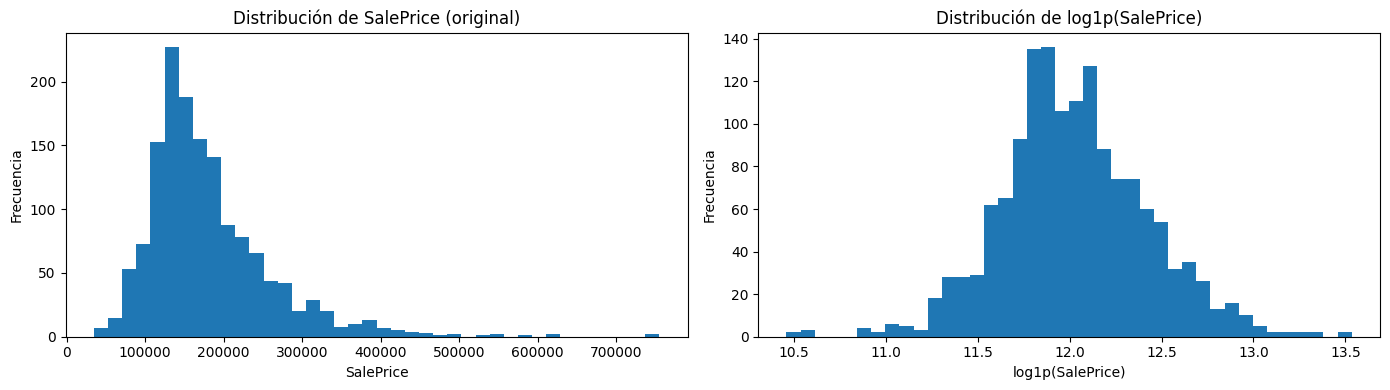

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y, bins=40)
axes[0].set_title("Distribución de SalePrice (original)")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frecuencia")

y_log = np.log1p(y)

axes[1].hist(y_log, bins=40)
axes[1].set_title("Distribución de log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


## Métrica del proyecto y validación: RMSE sobre log-precios

En Kaggle House Prices la métrica estándar es el error cuadrático medio raíz (RMSE) en escala logarítmica. Conceptualmente:
- El RMSE penaliza más los errores grandes que los pequeños (por el cuadrado).
- Al usar log-precios, el error se interpreta más en términos relativos (porcentuales aproximados), lo cual es razonable en precios.

Formalmente:
\[
RMSE = \sqrt{\frac{1}{n}\sum_i (\hat{y_i} - y_i)^2}
\]

En este notebook utilizaremos validación cruzada (Cross-Validation) para estimar el rendimiento de forma robusta:
- Usaremos `KFold` con `shuffle=True` porque este dataset no es temporal.
- Esto reduce el riesgo de que un split particular nos “engañe” (varianza del estimador).

Definimos además un `scorer` para que scikit-learn evalúe directamente RMSE (en negativo internamente).


In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## Preparación del Target en Escala Logarítmica

Tal como se observó en el análisis exploratorio, la variable objetivo `SalePrice`
presenta una distribución asimétrica con cola larga hacia la derecha.

Para estabilizar la varianza y aproximar la distribución a una forma más
simétrica, aplicamos la transformación:

    y_log = log(1 + SalePrice)

Esta transformación tiene varias ventajas:

1. Reduce el impacto de outliers.
2. Permite interpretar los errores de manera más proporcional.
3. Se alinea con la métrica utilizada en Kaggle (RMSE sobre log-precios).

A partir de este punto, todos los modelos se entrenarán usando `y_log`.


In [7]:
y_log = np.log1p(y)


## Separación de Variables Numéricas y Categóricas

El dataset contiene una mezcla de:

- Variables numéricas (ej. LotArea, GrLivArea, YearBuilt).
- Variables categóricas (ej. Neighborhood, HouseStyle, ExterQual).

Los modelos de scikit-learn requieren que todas las entradas sean numéricas.
Por tanto:

- Las variables categóricas deberán codificarse (One-Hot Encoding).
- Las variables numéricas deberán escalarse si utilizamos modelos lineales.

Identificamos ambos grupos automáticamente a partir del tipo de dato.


In [8]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))


Numéricas: 37
Categóricas: 43


## Construcción del Pipeline de Preprocesamiento

Creamos un `ColumnTransformer` que aplicará:

Para variables numéricas:
- Imputación con mediana (robusta frente a outliers).
- Escalado estándar (media 0, desviación estándar 1).

Para variables categóricas:
- Imputación con valor más frecuente.
- Codificación One-Hot.

El uso de Pipeline garantiza:

1. Reproducibilidad.
2. Ausencia de data leakage.
3. Integración automática en validación cruzada.


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## Modelos Base: Regularización Lineal

Comenzamos con modelos lineales regularizados:

- Ridge (regularización L2)
- Lasso (regularización L1)
- ElasticNet (combinación L1 + L2)

La regularización es fundamental en este dataset debido a:

- Gran número de variables tras One-Hot Encoding.
- Posible multicolinealidad.
- Riesgo de sobreajuste.

Evaluaremos el rendimiento usando validación cruzada con RMSE.


In [10]:
models = {
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5)
}

results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    
    scores = cross_val_score(clf, X, y_log, cv=cv, scoring=rmse_scorer)
    
    results.append((name, -scores.mean()))

pd.DataFrame(results, columns=["Model", "CV_RMSE"]).sort_values("CV_RMSE")


,Model,CV_RMSE
2,ElasticNet,0.142852
1,Lasso,0.144326
0,Ridge,0.146711


## Modelo No Lineal: Random Forest Regressor

Hasta ahora hemos probado modelos lineales regularizados.
Estos modelos asumen una relación aproximadamente lineal entre
las variables y el log-precio.

Sin embargo, en el mercado inmobiliario:

- Las relaciones suelen ser no lineales.
- Existen interacciones complejas entre variables.
- Puede haber efectos umbral (por ejemplo, calidad muy alta
  incrementa el precio de forma no proporcional).

Por ello, incorporamos un modelo basado en árboles:
Random Forest Regressor.

Ventajas:
- Captura relaciones no lineales.
- Modela interacciones automáticamente.
- Es robusto frente a outliers moderados.
- No requiere escalado estrictamente (aunque lo mantenemos por consistencia).


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf_model)
])

rf_scores = cross_val_score(rf_pipeline, X, y_log, cv=cv, scoring=rmse_scorer)

rf_rmse = -rf_scores.mean()
print("Random Forest CV RMSE:", rf_rmse)


Random Forest CV RMSE: 0.14479090182056964


## Comparación Global de Modelos

En esta celda comparamos los resultados obtenidos
entre modelos lineales regularizados y Random Forest.

La comparación se basa en la métrica RMSE sobre log-precios.

Un menor RMSE indica mejor capacidad predictiva
en validación cruzada.


In [12]:
results.append(("RandomForest", rf_rmse))

comparison_df = pd.DataFrame(results, columns=["Model", "CV_RMSE"])
comparison_df = comparison_df.sort_values("CV_RMSE")

comparison_df


,Model,CV_RMSE
2,ElasticNet,0.142852
1,Lasso,0.144326
3,RandomForest,0.144791
0,Ridge,0.146711


## Entrenamiento del Mejor Modelo

Seleccionamos el modelo con menor RMSE en validación cruzada
y lo entrenamos sobre todo el dataset de entrenamiento.

Esto nos permite:

- Obtener predicciones completas.
- Analizar residuos.
- Preparar el modelo para guardarlo y desplegarlo.


In [13]:
best_model_name = comparison_df.iloc[0]["Model"]

if best_model_name == "RandomForest":
    final_pipeline = rf_pipeline
else:
    best_linear = models[best_model_name]
    final_pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", best_linear)
    ])

final_pipeline.fit(X, y_log)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Análisis de Residuos

Calculamos los residuos:

residuo = y_real_log - y_pred_log

El análisis de residuos permite detectar:

- Sesgo sistemático.
- Heteroscedasticidad.
- Outliers.
- Patrones no capturados por el modelo.

En regresión, el análisis de errores es clave para entender
si el modelo está infraajustado o sobreajustado.


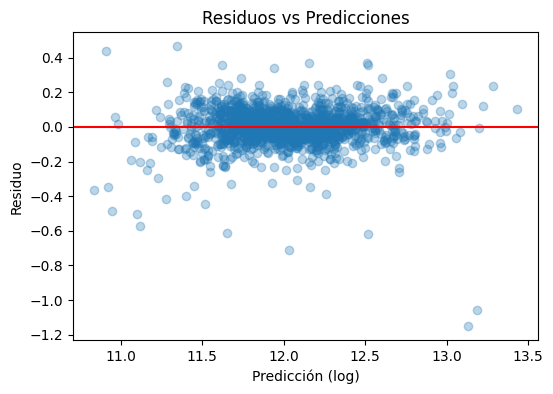

In [14]:
y_pred_log = final_pipeline.predict(X)
residuals = y_log - y_pred_log

plt.figure(figsize=(6,4))
plt.scatter(y_pred_log, residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.title("Residuos vs Predicciones")
plt.xlabel("Predicción (log)")
plt.ylabel("Residuo")
plt.show()



## Identificación de Posibles Outliers

Detectamos observaciones con residuos extremadamente altos
(en valor absoluto).

Estas viviendas pueden:

- Tener características atípicas.
- Estar mal registradas.
- Representar propiedades de lujo fuera del patrón general.

Identificarlos permite:

- Decidir si deben eliminarse.
- O simplemente analizar su impacto.


In [15]:
threshold = 3 * residuals.std()
outliers = np.abs(residuals) > threshold

print("Número de posibles outliers:", outliers.sum())


Número de posibles outliers: 22


## Mejora técnica: Tratamiento de Variables Numéricas Sesgadas

En datasets inmobiliarios es común que muchas variables numéricas
presenten distribuciones altamente asimétricas (por ejemplo, superficie del terreno).

La asimetría (skewness) puede afectar negativamente a modelos lineales.

Estrategia:
1. Identificar variables numéricas con alta asimetría.
2. Aplicar transformación logarítmica (log1p) solo a aquellas
   cuya skewness sea significativa.

Esto mejora:
- Estabilidad numérica.
- Comportamiento del modelo lineal.
- Generalización.


In [16]:
from scipy.stats import skew

numeric_data = X[numeric_features]

skewness = numeric_data.apply(lambda x: skew(x.dropna()))
skewed_features = skewness[skewness > 0.75].index.tolist()

print("Número de variables sesgadas:", len(skewed_features))
skewed_features[:10]


Número de variables sesgadas: 21


['MSSubClass',
 'LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF']

## Aplicación de Transformación Logarítmica a Variables Sesgadas

Aplicamos log1p solo a las variables identificadas.

Es importante hacerlo ANTES del pipeline de escalado,
pero manteniendo coherencia con el esquema de entrenamiento.

Esta transformación puede reducir el error del modelo lineal.


In [17]:
X_transformed = X.copy()

for col in skewed_features:
    X_transformed[col] = np.log1p(X_transformed[col])

X = X_transformed


## Re-entrenamiento del Modelo con Variables Mejoradas

Repetimos validación cruzada usando las variables transformadas.

Esto nos permite verificar si la transformación ha reducido el RMSE.


In [18]:
improved_results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    
    scores = cross_val_score(clf, X, y_log, cv=cv, scoring=rmse_scorer)
    improved_results.append((name, -scores.mean()))

rf_scores = cross_val_score(rf_pipeline, X, y_log, cv=cv, scoring=rmse_scorer)
improved_results.append(("RandomForest", -rf_scores.mean()))

pd.DataFrame(improved_results, columns=["Model", "CV_RMSE"]).sort_values("CV_RMSE")


,Model,CV_RMSE
2,ElasticNet,0.127241
1,Lasso,0.129600
0,Ridge,0.130395
3,RandomForest,0.144575


## Entrenamiento Final del Modelo Seleccionado

Seleccionamos el mejor modelo tras las mejoras
y lo entrenamos sobre todo el dataset.

Este modelo será el que:

- Se guarde para despliegue.
- Se use en la aplicación web.
- Genere la submission de Kaggle.


In [19]:
final_comparison = pd.DataFrame(improved_results, columns=["Model", "CV_RMSE"])
final_comparison = final_comparison.sort_values("CV_RMSE")

best_model_name = final_comparison.iloc[0]["Model"]

if best_model_name == "RandomForest":
    final_pipeline = rf_pipeline
else:
    best_linear = models[best_model_name]
    final_pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", best_linear)
    ])

final_pipeline.fit(X, y_log)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generación de Predicciones 

Preparamos el dataset test aplicando las mismas transformaciones.

Luego:
1. Generamos predicciones en escala log.
2. Aplicamos transformación inversa (expm1).
3. Creamos archivo submission.csv.


In [20]:
# Aplicar mismas transformaciones a test
test_transformed = test_df.copy()

for col in skewed_features:
    if col in test_transformed.columns:
        test_transformed[col] = np.log1p(test_transformed[col])

X_test = test_transformed

y_test_pred_log = final_pipeline.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_pred
})

submission.to_csv("submission.csv", index=False)

print("Archivo submission.csv generado correctamente.")


Archivo submission.csv generado correctamente.


## Guardado del Modelo para Despliegue

Guardamos el pipeline completo utilizando joblib.

Esto permite:
- Cargar el modelo en un servidor.
- Usarlo en una API.
- Integrarlo en una aplicación web.


In [21]:
joblib.dump(final_pipeline, "house_price_model.joblib")
print("Modelo guardado como house_price_model.joblib")


Modelo guardado como house_price_model.joblib


## Corrección del conjunto de features: eliminar `Id` (mejora de generalización)

Hasta ahora, el pipeline ha podido estar usando la columna `Id` como variable predictora si no se eliminó explícitamente.
Esto es una mala práctica porque `Id` no describe ninguna propiedad física del inmueble: es un identificador.

Riesgos de incluir `Id`:
- **Correlaciones espurias**: si el dataset está parcialmente ordenado, el modelo puede aprender patrones artificiales.
- **Sobreajuste**: el modelo “memoriza” artefactos del dataset en lugar de aprender relaciones causales (o al menos estables).
- **Peor rendimiento fuera de muestra**: aunque a veces `Id` parezca ayudar, suele degradar la generalización.

Objetivo de esta sección:
1) reconstruir `X` e `X_test` eliminando `Id`,
2) reentrenar el pipeline con el mismo preprocesamiento,
3) generar de nuevo la submission coherente con el modelo corregido,
4) guardar el modelo final para despliegue.


In [22]:
# Reconstruimos desde los dataframes originales para no arrastrar cambios previos
TARGET = "SalePrice"

y = train_df[TARGET].copy()
y_log = np.log1p(y)

# Eliminamos Id (y SalePrice en train)
X = train_df.drop(columns=[TARGET, "Id"]).copy()

# En test solo eliminamos Id
X_test_raw = test_df.drop(columns=["Id"]).copy()

print("Train X shape:", X.shape)
print("Test  X shape:", X_test_raw.shape)


Train X shape: (1460, 79)
Test  X shape: (1459, 79)


## Reidentificación de tipos y diagnóstico de faltantes (sin `Id`)

Al modificar el conjunto de features, conviene recalcular:
- qué columnas son numéricas,
- qué columnas son categóricas,
- y cuáles concentran más valores faltantes.

Esto es relevante porque el preprocesado depende del tipo:
- numéricas → imputación + escalado,
- categóricas → imputación + OneHotEncoding.

Además, House Prices es un dataset con abundante missingness, por lo que la imputación correcta es crítica.


In [23]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))

missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(15)


Numéricas: 36
Categóricas: 43


PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
dtype: float64

## Transformación de features numéricas sesgadas (log1p selectivo)

Muchas variables numéricas en House Prices tienen distribuciones muy asimétricas (colas largas).
Esto puede perjudicar especialmente a modelos lineales, porque:
- la relación con el target puede ser altamente no lineal,
- los outliers dominan el ajuste de los coeficientes,
- y el escalado estándar no corrige la asimetría.

Estrategia:
1) medimos skewness en variables numéricas,
2) seleccionamos las que superan un umbral (p.ej. 0.75),
3) aplicamos log1p SOLO a esas columnas en train y test para mantener coherencia.

Nota: aplicamos la transformación antes del pipeline, pero guardaremos la lista para repetirla en producción.


In [24]:
from scipy.stats import skew

skewness = X[numeric_features].apply(lambda s: skew(s.dropna()))
skewed_features = skewness[skewness > 0.75].index.tolist()

print("Variables sesgadas (skew > 0.75):", len(skewed_features))
print("Ejemplos:", skewed_features[:10])

# Aplicar log1p a esas columnas en train y test
X_trans = X.copy()
X_test_trans = X_test_raw.copy()

for col in skewed_features:
    X_trans[col] = np.log1p(X_trans[col])
    X_test_trans[col] = np.log1p(X_test_trans[col])

X = X_trans
X_test = X_test_trans


Variables sesgadas (skew > 0.75): 21
Ejemplos: ['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF']


## Preprocesado reproducible con ColumnTransformer + Pipeline (sin data leakage)

Diseñamos un pipeline de preprocesado que pueda:
- manejar missing values,
- convertir categóricas a numéricas (OneHot),
- normalizar escalas para modelos lineales.

Numéricas:
- Imputación por mediana (robusta ante outliers),
- Escalado estándar.

Categóricas:
- Imputación por moda,
- OneHotEncoder con `handle_unknown="ignore"` para evitar errores si aparecen categorías nuevas en producción.

Este enfoque, integrado en `Pipeline`, evita data leakage porque:
- en validación cruzada, los parámetros (medianas, medias, categorías) se aprenden SOLO con el fold de entrenamiento.


In [25]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## Reentrenamiento y selección del modelo (baseline sólido)

Probamos modelos lineales regularizados:
- Ridge (L2): reduce magnitud de coeficientes, útil con multicolinealidad.
- Lasso (L1): además puede “apagar” coeficientes (selección implícita).
- ElasticNet: combinación, útil cuando hay muchas features correlacionadas.

Tras OneHot, el número de features crece mucho, por eso la regularización suele ser clave.

Evaluamos con validación cruzada (KFold) usando RMSE sobre `y_log`.


In [26]:
models = {
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.0005, max_iter=20000, random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=20000, random_state=RANDOM_STATE)
}

cv_results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    scores = cross_val_score(pipe, X, y_log, cv=cv, scoring=rmse_scorer)
    cv_results.append((name, -scores.mean(), scores.std()))

cv_df = pd.DataFrame(cv_results, columns=["Model", "CV_RMSE_mean", "CV_RMSE_std"]).sort_values("CV_RMSE_mean")
cv_df


,Model,CV_RMSE_mean,CV_RMSE_std
1,Lasso,0.126267,0.022119
2,ElasticNet,0.126977,0.021493
0,Ridge,0.130422,0.021191


## Entrenamiento final del mejor modelo y nueva submission

Una vez seleccionado el mejor modelo por CV:
1) lo entrenamos con todos los datos de entrenamiento (X, y_log),
2) predecimos sobre `X_test`,
3) invertimos la transformación log con `expm1`,
4) generamos un `submission.csv` limpio y consistente con el modelo final.

Esta submission es la que debe subirse a Kaggle.


In [27]:
best_model_name = cv_df.iloc[0]["Model"]
best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[("preprocess", preprocess), ("model", best_model)])
final_pipeline.fit(X, y_log)

y_test_pred_log = final_pipeline.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_pred
})

# Opcional: redondear para legibilidad (Kaggle acepta float igualmente)
submission["SalePrice"] = submission["SalePrice"].round(2)

submission.to_csv("submission.csv", index=False)

print("✅ Modelo final entrenado:", best_model_name)
print("✅ submission.csv regenerado (sin usar Id como feature)")
submission.head()


✅ Modelo final entrenado: Lasso
✅ submission.csv regenerado (sin usar Id como feature)


,Id,SalePrice
0,1461,118670.23
1,1462,151475.71
2,1463,179991.01
3,1464,197042.69
4,1465,202157.14


## Guardado de artefacto para despliegue (modelo + metadatos)

Para despliegue real, no basta con guardar “solo el modelo”:
también necesitamos recordar transformaciones previas externas al pipeline (por ejemplo, log1p en features sesgadas).

Por eso guardamos un artefacto que incluye:
- pipeline entrenado (preprocesado + modelo),
- lista de columnas numéricas sesgadas que requieren log1p,
- listas de columnas (para validaciones de esquema).

Además definimos una función de inferencia que:
- recibe un DataFrame con las features “crudas” (sin Id, sin SalePrice),
- aplica log1p a las columnas sesgadas,
- ejecuta el pipeline,
- devuelve el precio en escala original.

Esto imita el comportamiento de una API en producción.


In [28]:
artifact = {
    "model": final_pipeline,
    "skewed_features": skewed_features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features
}

joblib.dump(artifact, "house_prices_artifact.joblib")
print("✅ Artefacto guardado: house_prices_artifact.joblib")

def predict_price(artifact: dict, raw_df: pd.DataFrame) -> np.ndarray:
    model = artifact["model"]
    skewed = artifact["skewed_features"]

    df = raw_df.copy()
    for col in skewed:
        if col in df.columns:
            df[col] = np.log1p(df[col])

    pred_log = model.predict(df)
    return np.expm1(pred_log)


✅ Artefacto guardado: house_prices_artifact.joblib


## Pruebas automáticas mínimas 

Añadimos tests sencillos con `assert` para validar invariantes del sistema:

- La función de inferencia no produce NaN/inf.
- Las predicciones son positivas.
- El número de predicciones coincide con el número de filas.
- El modelo puede ejecutarse con datos reales del test.

Estos tests ayudan a detectar roturas del pipeline antes del despliegue.


In [29]:
artifact_loaded = joblib.load("house_prices_artifact.joblib")

sample = X_test_raw.head(5).copy()
preds = predict_price(artifact_loaded, sample)

assert preds.shape[0] == len(sample), "❌ Nº predicciones != Nº filas"
assert np.isfinite(preds).all(), "❌ Hay NaN o inf en predicciones"
assert (preds > 0).all(), "❌ Hay predicciones no positivas"

print("✅ Tests OK. Predicciones ejemplo:", preds[:3])


✅ Tests OK. Predicciones ejemplo: [118670.22937758 151475.70821308 179991.01407955]


## Test de integración del backend (cliente → servidor)

Ahora comprobamos que el backend funciona como un servicio real:

1) Enviamos una petición a `/predict` con las features de una vivienda real tomada de `test.csv`.
2) Verificamos que el servidor devuelve un precio.
3) Enviamos feedback a `/feedback` con un precio real simulado (ej. el usuario conoce el precio final).
4) Comprobamos que el servidor crea/actualiza `api/data/feedback.csv`.

Esto valida:
- comunicación cliente-servidor,
- formato JSON correcto,
- y persistencia de nuevos datos para futuro reentrenamiento.


In [41]:
import numpy as np
import requests

BASE_URL = "http://127.0.0.1:8000"

# 1️ Tomamos una fila real del test
sample_features = X_test_raw.iloc[0].to_dict()

# 2️ Convertimos NaN e inf a None (que en JSON será null)
clean_features = {}
for k, v in sample_features.items():
    if v is None:
        clean_features[k] = None
    elif isinstance(v, float) and (np.isnan(v) or np.isinf(v)):
        clean_features[k] = None
    else:
        clean_features[k] = v

# 3 Enviamos al backend
pred_resp = requests.post(
    f"{BASE_URL}/predict",
    json={"features": clean_features}
)

print("Predict status:", pred_resp.status_code)
print("Predict json:", pred_resp.json())



Predict status: 200
Predict json: {'prediction_id': '31870b8b-0c6f-402d-8d91-58e91f715add', 'sale_price': 118670.23}


## Envío de Feedback al Servidor (Ciclo de Retroalimentación)

En esta sección simulamos el comportamiento de un usuario real que:

1. Recibe una predicción del modelo.
2. Posteriormente conoce el precio real de venta.
3. Envía ese precio real al servidor.

Este proceso implementa el concepto de **feedback loop en Machine Learning**:

Usuario → API → Almacenamiento → Futuro reentrenamiento

Técnicamente:

- Recuperamos la predicción obtenida anteriormente.
- Construimos un objeto JSON con:
  - Las features originales.
  - El precio real.
- Enviamos una petición HTTP POST al endpoint `/feedback`.

El servidor:
- Recibe los datos.
- Los almacena en `feedback.csv`.
- Permite que en el futuro se incorporen al dataset de entrenamiento.

Este mecanismo es clave en sistemas de ML en producción,
ya que permite mejorar el modelo con datos reales generados por usuarios.


In [36]:
fake_real_price = float(pred_resp.json()["sale_price"])

fb_payload = {
    "features": clean_features,
    "sale_price_real": fake_real_price
}

fb_resp = requests.post("http://127.0.0.1:8000/feedback", json=fb_payload)

print("Feedback status:", fb_resp.status_code)
print("Feedback json:", fb_resp.json())


Feedback status: 200
Feedback json: {'saved': True, 'row_id': 'd1494f60-8672-4c11-8088-69b529707e22'}
